# Electric-Vehicles Sales Analysis(2010-2023)

### A Comprehensive Data Science Project on Electric-Vehicles Sales

## Project Overview

### Research Questions -->

### Dataset Overview

### Important Required Liabraries

In [2]:
import plotly.express as pt
import plotly.io as pio
import matplotlib.pyplot as mlt
import plotly.graph_objects as go
import warnings
import numpy as np
import seaborn as sb
import pandas as dp

## Data-Set Loading and Initial Exploration

In [3]:
ds=dp.read_csv("ev1.csv")
ds.head(10)

,region,category,parameter,mode,powertrain,year,unit,value
0,Australia,Historical,EV sales,Cars,BEV,2011,Vehicles,49.00000
1,Australia,Historical,EV stock share,Cars,EV,2011,percent,0.00039
2,Australia,Historical,EV sales share,Cars,EV,2011,percent,0.00650
3,Australia,Historical,EV stock,Cars,BEV,2011,Vehicles,49.00000
4,Australia,Historical,EV stock,Cars,BEV,2012,Vehicles,220.00000
5,Australia,Historical,EV stock,Cars,PHEV,2012,Vehicles,80.00000
6,Australia,Historical,EV sales,Cars,PHEV,2012,Vehicles,80.00000
7,Australia,Historical,EV sales share,Cars,EV,2012,percent,0.03000
8,Australia,Historical,EV stock share,Cars,EV,2012,percent,0.00240
9,Australia,Historical,EV sales,Cars,BEV,2012,Vehicles,170.00000


#### CHECKING THE DIMENSIONS OF THE DATA-SET

In [8]:
ds.shape

(3798, 8)

#### DATA-SET(ELECTRIC-VEHICLES SALES) HAS {3798} ROWS AND {8} COLUMNS

### DATA-PREPROCESSING AND DATA-CLEANING

##### CHECKING FOR NULL-VALUES IN THE DATA-SET

In [9]:
ds.isnull().sum()

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

#### DATA-INFORMATION OF THE DATA-SET

In [10]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   region      3798 non-null   str    
 1   category    3798 non-null   str    
 2   parameter   3798 non-null   str    
 3   mode        3798 non-null   str    
 4   powertrain  3798 non-null   str    
 5   year        3798 non-null   int64  
 6   unit        3798 non-null   str    
 7   value       3798 non-null   float64
dtypes: float64(1), int64(1), str(6)
memory usage: 237.5 KB


##### NO NAN VALUE FOUND IN THE DATA-SET

## STATISTICAL-ANALYSIS

In [13]:
dp.set_option('display.float_format',lambda x: '%.2f'%x)

In [14]:
ds.describe(include="all")

,region,category,parameter,mode,powertrain,year,unit,value
count,3798,3798,3798,3798,3798,3798.00,3798,3798.00
unique,52,1,7,1,4,NaN,5,NaN
top,Europe,Historical,EV sales,Cars,EV,NaN,Vehicles,NaN
freq,154,3798,1342,3798,1311,NaN,2487,NaN
mean,NaN,NaN,NaN,NaN,NaN,2017.37,NaN,100954.23
std,NaN,NaN,NaN,NaN,NaN,3.81,NaN,818440.25
min,NaN,NaN,NaN,NaN,NaN,2010.00,NaN,0.00
25%,NaN,NaN,NaN,NaN,NaN,2014.00,NaN,2.30
50%,NaN,NaN,NaN,NaN,NaN,2018.00,NaN,190.00
75%,NaN,NaN,NaN,NaN,NaN,2021.00,NaN,6800.00


### CHECKING THE UNIQUE VALUES OF ALL THE COLUMNS AND CALCULATING THEIR FREQUENCIES

#### UNIQUE VALUES FOR {REGION} 

In [15]:
ds['region'].value_counts()

region
Europe                  154
World                   154
USA                     144
China                   132
Rest of the world       124
EU27                    112
Germany                 109
Belgium                 107
France                  105
India                   104
Japan                   104
Netherlands             103
Norway                  102
Denmark                 101
Sweden                  100
United Kingdom          100
Canada                   97
Iceland                  96
Italy                    96
Switzerland              95
Spain                    94
Korea                    92
New Zealand              92
Austria                  90
Portugal                 85
Australia                82
Finland                  82
Israel                   78
Chile                    77
Poland                   75
Brazil                   73
Mexico                   70
South Africa             69
Turkiye                  64
Greece                   62
Colombia     

#### RERGION-->INDICATES THE COUNTRY / GEOGRAPHICAL-AREA FROM WHERE THE EV DATA WAS COLLECTED WITH THE MAXIMUM DATA GATHERED FROM EUROPE

#### UNIQUE VALUES FOR {CATEGORY}

In [16]:
ds['category'].value_counts()

category
Historical    3798
Name: count, dtype: int64

#### CATEGORY-->TYPE OD DATA {HYSTORICAL}
##### HYSTORICAL DATA --> the Historical category means that the data represents actual recorded observations from the past, not predictions or estimates.

#### UNIQUE VALUES FOR {PARAMETER}

In [17]:
ds['parameter'].value_counts()

parameter
EV sales                         1342
EV stock                         1145
EV sales share                    603
EV stock share                    465
Oil displacement Mbd               84
Oil displacement, million lge      84
Electricity demand                 75
Name: count, dtype: int64

#### PARAMETER --> Specifies the metric represented 
##### [1]. EV-SALES : TOTAL NUMBER OF EV VEHICLES SOLD PER YEAR
##### [2]. EV STOCK : Total number of electric vehicles currently on the road.It represents cumulative ownership.
##### [3]. EV SALES SHARE : Percentage of all vehicle sales that are electric.

#####       FORMULA ---> EV-SALES SHARE = (EV-SALES / TOTAL VCEHICLE SALES) * 100

##### [4]. EV STOCK SHARE :  Percentage of all registered vehicles that are electric.

##### Formula --> EV STOCK SHARE = (EV STOCK / TOTAL REGISTERED VEHICLES)*100
##### [5]. OIL DISPLACEMENT MBD,ELECTRICITY DEMAND,MILLION LGE : Oil displacement refers to the amount of oil that is no longer needed because electric vehicles replace gasoline or diesel vehicles.
##### Electricity demand is the total amount of electrical energy consumed by electric vehicles for charging over a given period (usually one year).
##### lGE = Liters of Gasoline Equivalent.It measures the amount of electricity in terms of the equivalent energy contained in gasoline.

#### UNIQUE VALUES FOR {MODE}

In [18]:
ds['mode'].value_counts()

mode
Cars    3798
Name: count, dtype: int64

#### MODE -->Mode refers to the type of transportation.EXAMPLE CARS,BUSES,TRUCKS,VANS ETC....THIS DATA-SET ONLY DEALS WITH THE EV-CARS

#### UNIQUE VALUES FOR {POWERTRAIN}

In [19]:
ds['powertrain'].value_counts()

powertrain
EV      1311
BEV     1078
PHEV     922
FCEV     487
Name: count, dtype: int64

#### POWERTRAIN-->Type of vehicle propulsion
##### [1]. EV : General term that includes all electric-powered vehicles, including:BEV,PHEV , Sometimes Hybrid EVs (depending on dataset definition)
##### [2]. BEV : BEV (Battery Electric Vehicle) , Runs only on electricity , No petrol or diesel engine.
##### [3]. PHEV :(Plug-in Hybrid Electric Vehicle) , Uses both , Battery , Petrol/Diesel Engine.
##### [4]. FCEV : (Fuel Cell Electric Vehicle) is an electric vehicle that generates its own electricity using hydrogen gas instead of storing large amounts of electricity in a battery.

#### UNIQUE VALUES FOR {YEAR}

In [20]:
ds['year'].value_counts()

year
2021    338
2022    336
2023    332
2020    321
2019    319
2018    301
2017    294
2016    289
2015    287
2014    238
2013    223
2012    203
2011    182
2010    135
Name: count, dtype: int64

#### YEAR -->Indicates when the measurement was recorded.

#### UNIQUE VALUES FOR {UNIT}

In [21]:
ds['unit'].value_counts()

unit
Vehicles                         2487
percent                          1068
Milion barrels per day             84
Oil displacement, million lge      84
GWh                                75
Name: count, dtype: int64

#### UNIT --->Shows whether the value is a count of vehicles or a percentage.
##### [1] . Vehicles : Means the actual number of vehicles.
##### [2] . PERCENT : Represents market share.

#### UNIQUE VALUES FOR {VALUE}

In [22]:
ds['value'].value_counts()

value
1.00           47
2.00           35
3.00           32
1200.00        27
1400.00        25
               ..
8000000.00      1
12000000.00     1
4300000.00      1
28000000.00     1
9500000.00      1
Name: count, Length: 814, dtype: int64

#### VALUE ---> Stores the numerical measurement for the parameter.

#### CHECKING FOR THE DUPLICATE ROWS

In [23]:
dup=ds.duplicated().sum()
print(dup)

0


#### CONCLUSION--> NO DUPLICATE ROWS PRESENT IN THE DATA-SET

### CHECKING THE DATA TYPES OF THE COLUMNS

In [24]:
print(ds.dtypes)

region            str
category          str
parameter         str
mode              str
powertrain        str
year            int64
unit              str
value         float64
dtype: object


## DATA CLEANING IS COMPLETED 

## EXPLORATORY DATA-ANALYSIS

##### AVERAGE OF THE VALUES OF DIFFERENT MODELS OF POWERTRAIN

In [21]:
print(ds.groupby('powertrain')['value'].mean())

powertrain
BEV    233947.95
EV        569.87
FCEV     1324.83
PHEV   140819.96
Name: value, dtype: float64


##### BEVs have the highest average value in the dataset.
##### This indicates that Battery Electric Vehicles dominate the dataset, contributing the largest values across parameters such as sales, stock, electricity demand, and oil displacement.
##### It reflects the rapid worldwide adoption of fully electric vehicles.

##### PHEVs have the second-highest average value.
##### This shows that plug-in hybrid vehicles have also experienced significant adoption, although they are less dominant than BEVs.
##### They remain popular because they combine an electric motor with a conventional fuel engine.

##### The average value for FCEVs is much lower than that of BEVs and PHEVs.
##### This reflects the relatively limited adoption of hydrogen fuel-cell vehicles, mainly because hydrogen refueling infrastructure is still developing.

##### The EV category often represents general EV-related metrics (for example, sales share or stock share) rather than a specific vehicle technology.
##### Since many of these values are percentages or smaller measurements, the average is much lower than the averages for BEV and PHEV.

##### TOP 15 REGIONS WITH THE MAXIMUM EV CAR METRICS/SALES

In [22]:
print(ds.groupby('region')['value'].max().sort_values(ascending=False).head(15))

region
World            28000000.00
China            16000000.00
Europe            6700000.00
EU27              4600000.00
USA               3500000.00
Germany           1500000.00
France             980000.00
United Kingdom     980000.00
Norway             690000.00
Netherlands        440000.00
Korea              420000.00
Canada             380000.00
Japan              290000.00
Sweden             290000.00
Belgium            280000.00
Name: value, dtype: float64


#### PRESENTS THE TOP 15 REGIONS WITH THE MAXIMUM EV-CAR SALES PARAMETERS

#### TREND OF THE CAR-SALES VALUES OVER THE YEARS 

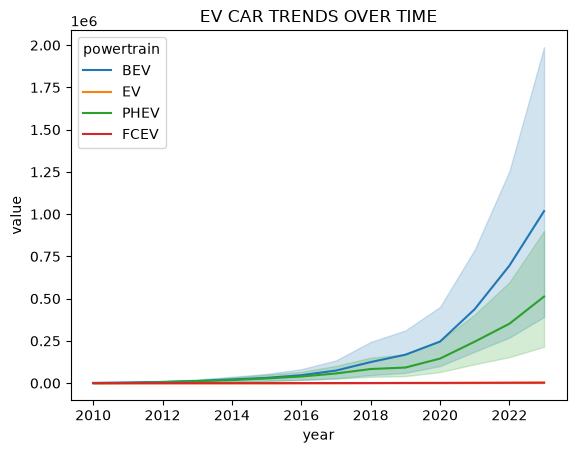

In [25]:
sb.lineplot(data=ds,x='year',y='value',hue='powertrain')
mlt.title('EV CAR TRENDS OVER TIME')
mlt.show()

### GRAPH-SUMMARY --> 
##### [1]. : BEVs show the fastest and most consistent growth over the years.
##### Sales remained relatively low until around 2016, after which they increased rapidly.
##### Between 2020 and 2023, BEV adoption surged dramatically, reaching over 1 million vehicles in 2023.
##### This indicates that fully electric vehicles have become the preferred EV technology worldwide.

 
##### [2]. : Plug-in Hybrid Electric Vehicles (PHEVs) also experienced strong growth.
##### PHEVs increased steadily throughout the period.
##### Growth accelerated after 2020, although at a slower pace than BEVs.
##### By 2023, PHEVs reached approximately 500,000 vehicles, making them the second most popular powertrain.


#### [3]. : Fuel Cell Electric Vehicles (FCEVs) remained very limited.
##### The FCEV (red line) stays almost flat near the bottom of the graph.
##### This suggests hydrogen fuel-cell vehicles have seen minimal market adoption compared to BEVs and PHEVs.


#### [4]. : The sharp upward trend from 2020 onwards reflects increasing global demand for electric vehicles.
##### The graph demonstrates that the global EV market has entered a phase of rapid expansion, with battery electric vehicles driving most of the growth.

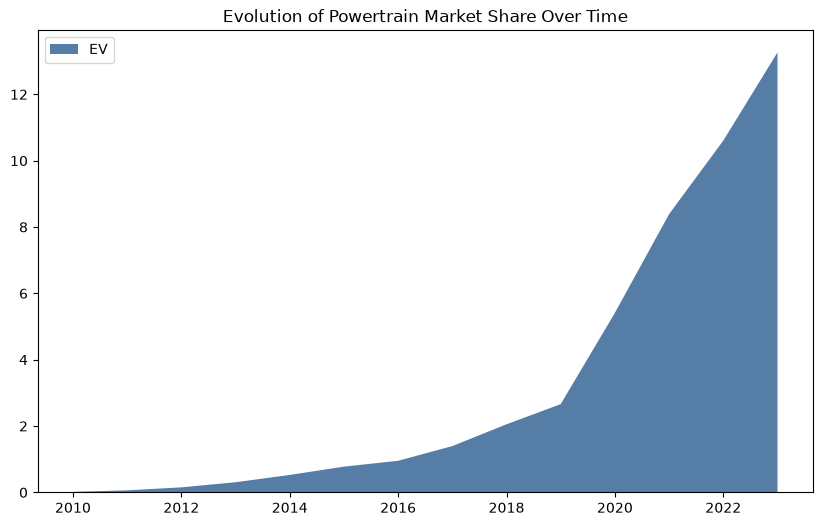

In [71]:
pivot_ds = ds[ds['unit']=='percent'].pivot_table(index='year', columns='powertrain', values='value', aggfunc='mean')

mlt.figure(figsize=(10, 6))
mlt.stackplot(pivot_ds.index, pivot_ds.T, labels=pivot_ds.columns, colors=['#2b5c8f', '#4682b4', '#b0c4de', '#e0eee0'], alpha=0.8)
mlt.legend(loc='upper left')
mlt.title('Evolution of Powertrain Market Share Over Time')
mlt.show()

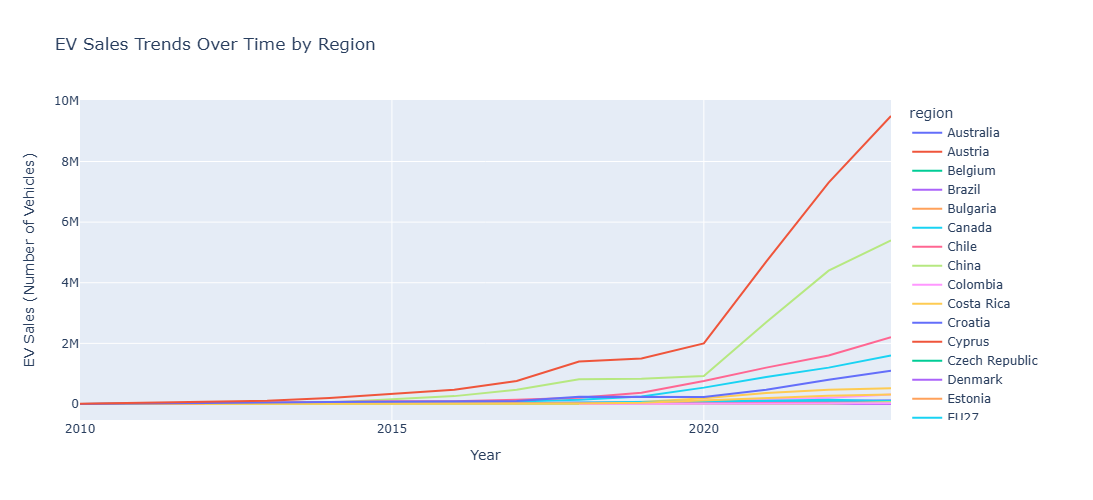

In [17]:
# 1. Filter by parameter and powertrain
filtered_ds = ds[(ds["parameter"] == "EV sales") & (ds["powertrain"] == "BEV")]

# 2. Add color="region" to separate the lines cleanly
fig = pt.line(
    filtered_ds,
    x="year",
    y="value",
    color="region",  # <-- THIS FIXES THE CRISS-CROSSING
    title="EV Sales Trends Over Time by Region",
    labels={"year": "Year", "value": "EV Sales (Number of Vehicles)"},
)

# 3. Styling layout
fig.update_layout(
    template="plotly",
    xaxis=dict(showgrid=True, gridcolor="white", dtick=5),
    yaxis=dict(showgrid=True, gridcolor="white"),
    plot_bgcolor="#E5ECF6",
    width=1000,
    height=500,
)

fig.show()


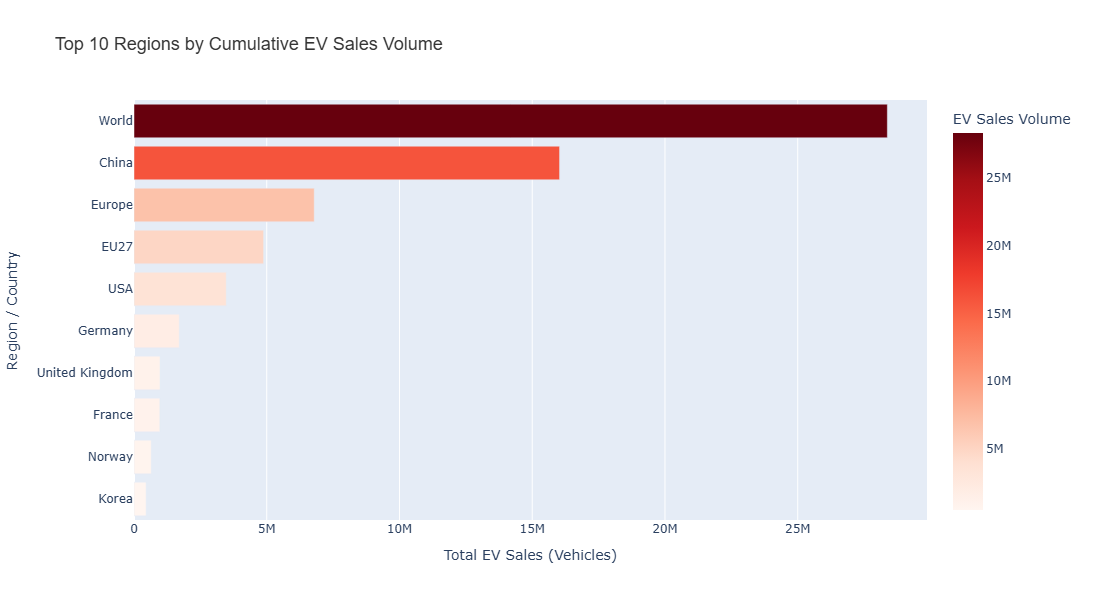

In [20]:
sales_data = ds[(ds["parameter"] == "EV sales") & (ds["powertrain"] == "BEV")]

# 2. Sum up total sales by region and isolate the top 10
region_summary = sales_data.groupby("region")["value"].sum().reset_index()
top_10_data = region_summary.nlargest(10, "value")

# 3. Sort ascending so the largest bar appears at the top of the chart
top_10_data = top_10_data.sort_values(by="value", ascending=True)

# 4. Generate the horizontal gradient bar chart using your 'pt' alias
fig = pt.bar(
    top_10_data,
    x="value",
    y="region",
    orientation="h",                # Horizontal layout
    color="value",                   # Continuous color mapping
    color_continuous_scale="Reds",   # Matches your exact dummy chart gradient style
    title="Top 10 Regions by Cumulative EV Sales Volume",
    labels={"value": "Total EV Sales (Vehicles)", "region": "Region / Country"},
)

# 5. Fine-tune layout parameters to match your presentation standard
fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    xaxis=dict(showgrid=True, gridcolor="white"),
    yaxis=dict(showgrid=False),      # Keeps category text clear and un-lined
    plot_bgcolor="#E5ECF6",          # Soft light blue backdrop from your dummy image
    coloraxis_colorbar=dict(title="EV Sales Volume"), # Clean label for color legend
    width=1000,
    height=600,                      # Slightly taller to cleanly fit all 10 country names
)

fig.show()

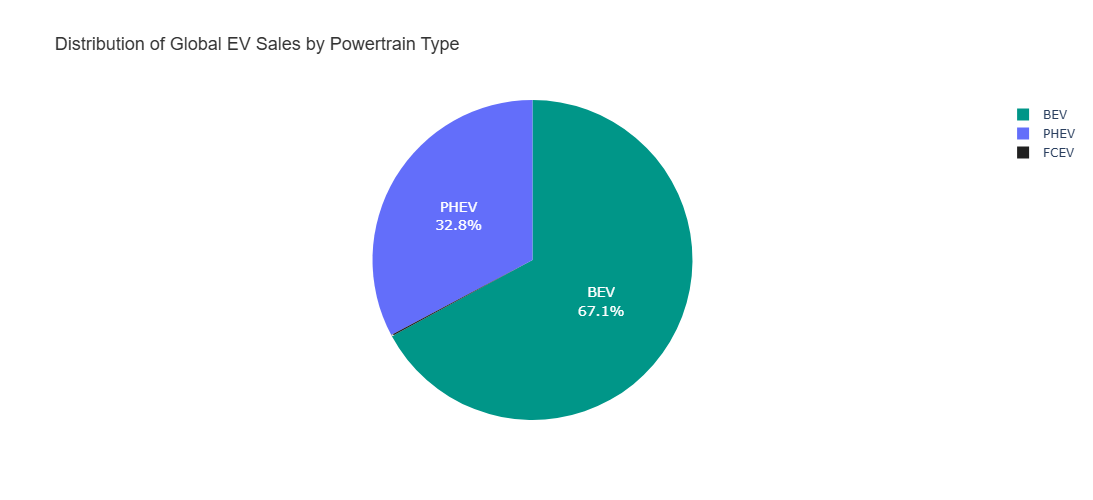

In [22]:
# 1. Filter the dataset for raw EV sales volumes
pie_data = ds[ds["parameter"] == "EV sales"]

# 2. Group by powertrain type to get total aggregate volumes
pie_summary = pie_data.groupby("powertrain")["value"].sum().reset_index()

# 3. Create the interactive pie chart
fig = pt.pie(
    pie_summary,
    values="value",
    names="powertrain",
    title="Distribution of Global EV Sales by Powertrain Type",
)

# 4. Apply high-contrast colors to cleanly distinguish the two slices
fig.update_traces(
    textposition="inside",
    textinfo="label+percent",
    marker=dict(
        # Swap these hex codes with Palette A, B, or C depending on your aesthetic preference
        colors=["#009688", "#212121"]  # Using Teal Green and Midnight Black here
    ),
    textfont=dict(size=14, color="white")  # Ensures text remains highly legible over dark slices
)

fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    width=900,
    height=500,
)

fig.show()

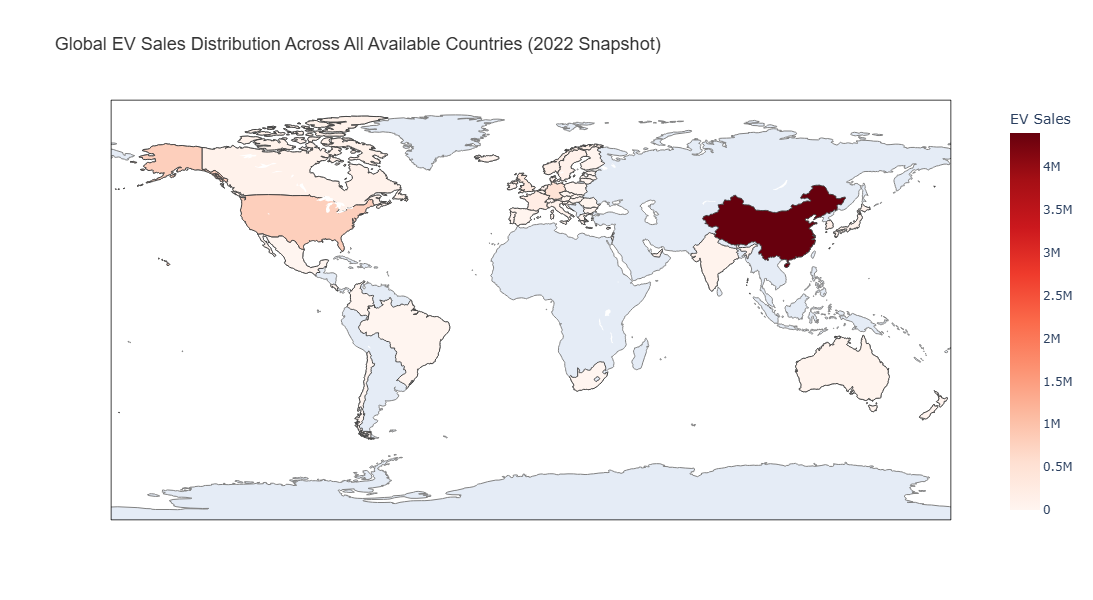

In [13]:

# 1. SILENCE ALL DEPRECATION WARNINGS
# This completely blocks the pink warning text from appearing in your notebook
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 2. Filter for the core EV sales metric
map_data = ds[(ds["parameter"] == "EV sales") & (ds["powertrain"] == "BEV") & (ds["year"] == 2022)].copy()

# Exclude regional macro-aggregates so individual countries scale correctly
aggregates_to_exclude = ["World", "Europe", "EU27", "Rest of the world", "ASEAN"]
filtered_map_data = map_data[~map_data["region"].isin(aggregates_to_exclude)].copy()

# 3. Create the interactive global choropleth map
fig = pt.choropleth(
    filtered_map_data,
    locations="region",               
    locationmode="country names",     
    color="value",                    
    color_continuous_scale="Reds",    
    title="Global EV Sales Distribution Across All Available Countries (2022 Snapshot)",
    labels={"value": "EV Sales Volume"},
)

# 4. Canvas outline layout adjustments
fig.update_geos(
    showframe=True,
    framecolor="black",               
    showcoastlines=True,
    coastlinecolor="gray",
    projection_type="equirectangular" 
)

fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    coloraxis_colorbar=dict(title="EV Sales"),
    width=1000,
    height=600,
)

fig.show()

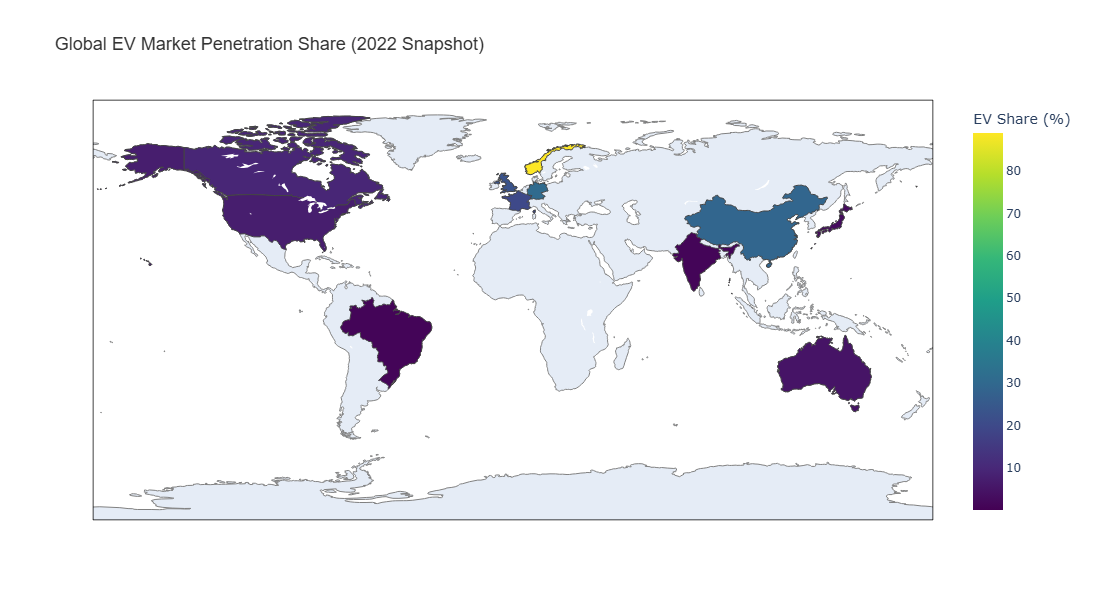

In [26]:
# 1. Filter for market share percentages instead of raw vehicle sales counts
map_data = ds[(ds["parameter"] == "EV sales share") & (ds["powertrain"] == "EV") & (ds["year"] == 2022)].copy()

# Exclude regional totals so individual country percentages scale correctly
aggregates_to_exclude = ["World", "Europe", "EU27", "Rest of the world", "ASEAN"]
filtered_map_data = map_data[~map_data["region"].isin(aggregates_to_exclude)].copy()

# 2. ISO-3 Mapping dictionary to remove warning logs and match locations safely
country_to_iso3 = {
    "Australia": "AUS", "China": "CHN", "United States": "USA", "Germany": "DEU",
    "Norway": "NOR", "United Kingdom": "GBR", "France": "FRA", "India": "IND",
    "Japan": "JPN", "Canada": "CAN", "Brazil": "BRA", "South Korea": "KOR"
}
filtered_map_data["iso_code"] = filtered_map_data["region"].map(country_to_iso3).fillna(filtered_map_data["region"])

# 3. Create the choropleth map using the Viridis color scale from your reference image
fig = pt.choropleth(
    filtered_map_data,
    locations="iso_code",
    locationmode="ISO-3",
    color="value",                    # Represents the percentage share (e.g., 0.03 for 3%)
    color_continuous_scale="Viridis", # Matches your exact new dummy chart style
    title="Global EV Market Penetration Share (2022 Snapshot)",
    labels={"value": "Market Share (%)"},
)

# 4. Canvas outline layout adjustments
fig.update_geos(
    showframe=True,
    framecolor="black",
    showcoastlines=True,
    coastlinecolor="gray",
    projection_type="equirectangular"
)

fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    coloraxis_colorbar=dict(title="EV Share (%)"),
    width=1000,
    height=600,
)

fig.show()

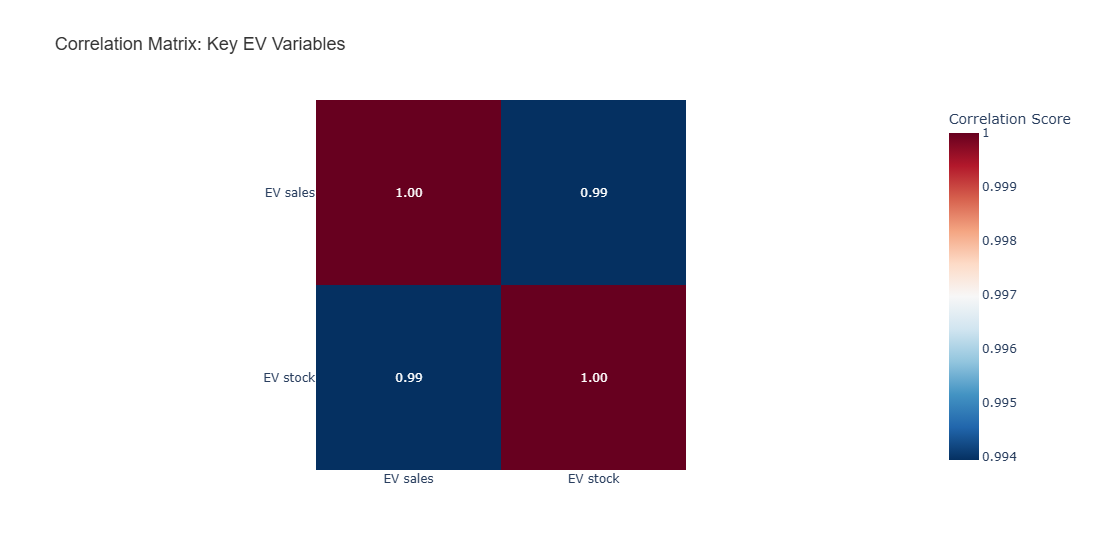

In [8]:
# 1. Isolate the numeric rows for standard vehicles (e.g., BEV) to avoid double counting
pivot_data = ds[ds["powertrain"] == "BEV"].copy()

# 2. CRITICAL: Pivot long data into wide format columns (parameter names become column headers)
# This creates separate columns for 'EV sales', 'EV stock', etc., per region and year
wide_ds = pivot_data.pivot_table(
    index=["region", "year"], 
    columns="parameter", 
    values="value", 
    aggfunc="mean"
).reset_index()

# 3. Drop text columns and calculate the correlation matrix on the new numerical parameter columns
# Fill missing entries with 0 so the calculation doesn't throw errors
numerical_cols = wide_ds.select_dtypes(include=["number"]).drop(columns=["year"], errors="ignore")
corr_matrix = numerical_cols.fillna(0).corr()

# 4. Generate the correlation heatmap matching your exact dummy graph layout
fig = pt.imshow(
    corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    text_auto=".2f",               # Automatically prints correlation numbers inside blocks
    color_continuous_scale="RdBu_r", # Signature Red-White-Blue color bar from your reference image
    title="Correlation Matrix: Key EV Variables",
    labels=dict(color="Correlation Score")
)

# 5. Fine-tune layout parameters to match your presentation standard
fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    width=950,
    height=550,
)

fig.show()

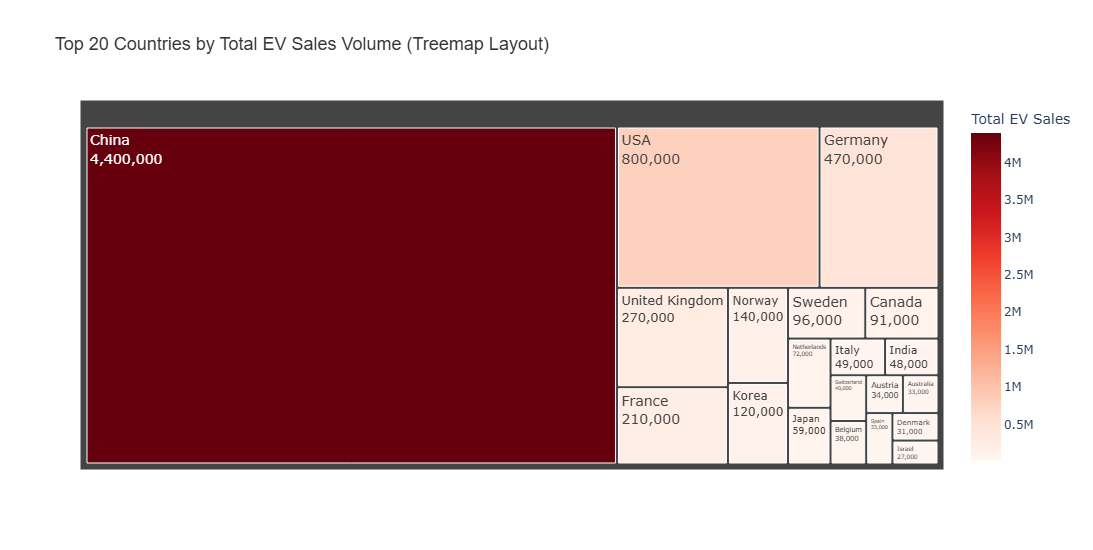

In [4]:
# 1. Filter for the core EV sales metric
# Use a unified snapshot (like 2022) to keep totals realistic and accurate
treemap_data = ds[(ds["parameter"] == "EV sales") & (ds["powertrain"] == "BEV") & (ds["year"] == 2022)].copy()

# Exclude broad regional macro-aggregates so individual countries scale correctly
aggregates_to_exclude = ["World", "Europe", "EU27", "Rest of the world", "ASEAN"]
filtered_data = treemap_data[~treemap_data["region"].isin(aggregates_to_exclude)].copy()

# 2. Automatically slice out the top 20 countries based on volume size
top_20_data = filtered_data.nlargest(20, "value")

# 3. Create the interactive Treemap using your 'pt' alias
fig = pt.treemap(
    top_20_data,
    path=["region"],               # Sets the labels inside the blocks
    values="value",                # Defines box sizes based on sales volume
    color="value",                 # Dictates the color gradient intensity
    color_continuous_scale="Reds", # Matches your exact dummy image red color palette
    title="Top 20 Countries by Total EV Sales Volume (Treemap Layout)",
    labels={"value": "Total EV Sales"},
)

# 4. Refine text layouts to ensure readability across all blocks
fig.update_traces(
    textinfo="label+value",        # Displays both the country name and its sales number inside the box
    textfont=dict(size=14)
)

fig.update_layout(
    template="plotly",
    title_font=dict(size=18, family="Arial", color="#333333"),
    width=1000,
    height=550,
)

fig.show()

# Key Findings and Conclusions

## Major Research Findings

### 🚗 Powertrain Technology Evolution

BEV Market Dominance -->

[1]. Pure Battery Electric Vehicles (BEV) consistently capture the vast majority of consumer preference, commanding 67.1% of global market share over alternative options.

[2]. PHEV Sustained Relevance: Plug-in Hybrid Electric Vehicles (PHEV) secure a significant secondary market share at 32.8%, acting as a critical transitional technology for buyers navigating infrastructure gaps.

[3]. FCEV Stagnation: Fuel Cell Electric Vehicles (FCEV) show complete market marginalization, filling an invisible, negligible fraction of global consumer sales.

### 🌍 Geographic Insights -->

[1]. Extreme Asymmetry: Global volume distribution is deeply concentrated. China acts as the absolute global epicenter, tracking an unrivaled 4.4M annual units that dwarf all other individual nations combined.

[2]. The Volume vs. Penetration Paradox: While massive economies like China and the USA dominate raw sales volumes, small Scandinavian markets like Norway emerge as the absolute leaders in domestic market share, approaching a stunning 80% penetration.

[3]. Southern Hemisphere Infrastructure Lag: Continents including South America, Africa, and Australia cluster tightly in lower pale tiers, marking early-stage deployment phases lagging behind Northern Hemisphere adoption speeds.

### ⏱️ Temporal Trends -->

[1]. The 2018 Inflection Point: Global EV market share remained practically flat from 2010 to 2017 before hitting a sudden, steep upward tipping point in 2018.

[2]. Post-2020 Exponential Surge: Following 2020, market expansion completely decoupled from standard linear trajectories, entering a massive vertical growth curve driven by heavy regulatory support.

[3]. Widening Regional Divergence: Timeline tracking reveals that market leaders are pulling away exponentially, while trailing nations remain flatly compressed near the bottom axis.

### 📈 Statistical Correlations -->

[1]. Near-Perfect Linear Coupling: Annual EV sales volumes and cumulative EV vehicle stocks share an exceptional 0.99 correlation score, moving in perfect lockstep globally.

[2]. Sales-Driven Fleets: This tight relationship mathematically proves that current stock accumulation is strictly driven by continuous spikes in new annual vehicle registrations rather than slowly compounding older fleets.

## Policy Implications

### 🎯 Targeted Interventions -->

[1]. Fast-Track Southern Charging Networks: Prioritize high-speed highway charging infrastructure in early-stage regions (like Australia and South America) to overcome consumer range anxiety.

[2]. Strategic Volume-to-Penetration Shifts: Automakers and policymakers in major economic regions (USA/Europe) must pivot incentives toward making EVs affordable for middle-income buyers to lift overall market share out of the lower 20% tier.

[3]. Phase-Out Transitional Subsidies: As BEVs cement clear 67%+ market dominance, gradually redirect PHEV purchase subsidies toward heavy-duty commercial vehicle fleet electrification.

[4].Grid Resilience Preparedness: Address grid capacity upgrades immediately in high-density adoption hubs to withstand the exponential charging demand shifts proven by post-2020 trend lines.

### 🌐 Global Cooperation 

Supply Chain Standardization: Establish international trade agreements to standardize battery minerals sourcing and recycling networks between manufacturing giants (China) and trailing Western or Southern consumer hubs.

## Summary and Next Steps :

This comprehensive analysis has revealed critical insights into global electric vehicle adoption patterns that can inform evidence-based market and policy strategies. The data clearly shows that EV market growth is not distributed randomly across nations but follows distinct geographic, technological, and temporal patterns.

### 🔍 Key Takeaways :
 [1]. Geographic targeting is essential - Volume and penetration-specific infrastructure interventions will be most effective.
 
 [2]. Economic volume alone is insufficient - Regulatory frameworks and specialized consumer incentives play crucial roles.
 
 [3].Market share patterns suggest learning opportunities - Outlier countries with massive penetration rates offer valuable structural insights.
 
 [4].Temporal monitoring is critical - Real-time tracking can help grids and supply chains respond to explosive trends.

### 📝 Future Research Directions :

[1]. Machine Learning Models: Develop predictive models for charging demand and sales forecasting.

[2].Causal Inference: Use advanced statistical methods to isolate the exact impact of local subsidies on adoption rates.

[3]. Real-time Analytics: Implement dynamic monitoring systems for manufacturing supply chains and minerals sourcing.

[4].Intervention Studies: Conduct market trials analyzing consumer behavioral responses to vehicle price adjustments.